# MENTORÍA 06
# **Cambio climático y ML: cómo mitigar las emisiones de CO2 mediante la reducción del consumo energético en construcciones edilicias**

**TP N°3: Aprendizaje supervisado o no supervisado**

Fecha de entrega: **22 de septiembre**

Integrantes:


* Valeria Becker
* Marcos Asís Rodríquez
* Ángel Valentino Indorato
* Pablo Boggetti

# 1.IMPORTACION DE LIBRERIAS

In [1]:
#%pip install missingno

In [2]:
#%pip install optuna

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
#import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# 2.ESCENARIOS

Se muestra el codigo para generar los X_train, X_test, y_train e y_test para cada escenario

## PASOS EN COMUN

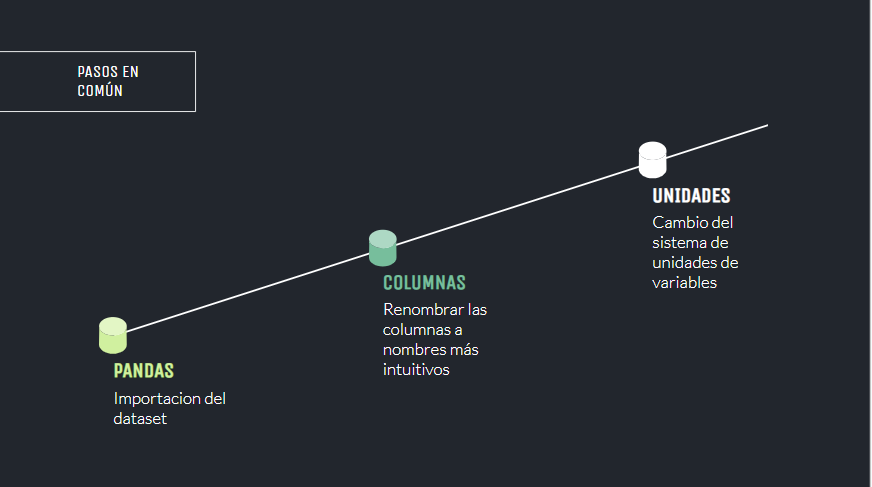

In [4]:
# 1) Importacion del data set
df = pd.read_csv("data.csv")

# 2) Renombrar columnas
df=df.rename(columns={
    'Year_Factor': 'factor_año',
    'State_Factor': 'factor_estado',
    'building_class': 'clase_edificio',
    'facility_type': 'tipo_instalacion',
    'floor_area': 'area_edificio',
    'year_built': 'año_construccion',
    'energy_star_rating': 'calificacion_energystar',
    'ELEVATION': 'elevacion',
    'january_min_temp': 'enero_temp_min',
    'january_avg_temp': 'enero_temp_promedio',
    'january_max_temp': 'enero_temp_max',
    'february_min_temp': 'febrero_temp_min',
    'february_avg_temp': 'febrero_temp_promedio',
    'february_max_temp': 'febrero_temp_max',
    'march_min_temp': 'marzo_temp_min',
    'march_avg_temp': 'marzo_temp_promedio',
    'march_max_temp': 'marzo_temp_max',
    'april_min_temp': 'abril_temp_min',
    'april_avg_temp': 'abril_temp_promedio',
    'april_max_temp': 'abril_temp_max',
    'may_min_temp': 'mayo_temp_min',
    'may_avg_temp': 'mayo_temp_promedio',
    'may_max_temp': 'mayo_temp_max',
    'june_min_temp': 'junio_temp_min',
    'june_avg_temp': 'junio_temp_promedio',
    'june_max_temp': 'junio_temp_max',
    'july_min_temp': 'julio_temp_min',
    'july_avg_temp': 'julio_temp_promedio',
    'july_max_temp': 'julio_temp_max',
    'august_min_temp': 'agosto_temp_min',
    'august_avg_temp': 'agosto_temp_promedio',
    'august_max_temp': 'agosto_temp_max',
    'september_min_temp': 'septiembre_temp_min',
    'september_avg_temp': 'septiembre_temp_promedio',
    'september_max_temp': 'septiembre_temp_max',
    'october_min_temp': 'octubre_temp_min',
    'october_avg_temp': 'octubre_temp_promedio',
    'october_max_temp': 'octubre_temp_max',
    'november_min_temp': 'noviembre_temp_min',
    'november_avg_temp': 'noviembre_temp_promedio',
    'november_max_temp': 'noviembre_temp_max',
    'december_min_temp': 'diciembre_temp_min',
    'december_avg_temp': 'diciembre_temp_promedio',
    'december_max_temp': 'diciembre_temp_max',
    'cooling_degree_days': 'grados_dia_enfriamiento',
    'heating_degree_days': 'grados_dia_calefaccion',
    'precipitation_inches': 'precipitacion_mm',
    'snowfall_inches': 'nevada_mm',
    'snowdepth_inches': 'profundidad_nieve_mm',
    'avg_temperature': 'temperatura_promedio',
    'days_below_30F':'dias_menos_1C',
    'days_below_20F': 'dias_menos_6C',
    'days_below_10F': 'dias_menos_12C',
    'days_below_0F': 'dias_menos_18C',
    'days_above_80F': 'dias_mas_27C',
    'days_above_90F': 'dias_mas_32C',
    'days_above_100F': 'dias_mas_38C',
    'days_above_110F': 'dias_mas_43C',
    'direction_max_wind_speed': 'direccion_velocidad_viento_maxima',
    'direction_peak_wind_speed': 'direccion_velocidad_viento_pico',
    'max_wind_speed': 'velocidad_viento_maxima',
    'days_with_fog': 'dias_con_niebla',
    'site_eui': 'consumo',
})


# 3) Cambio de unidades
    # consumo -> kBtu/ft² to kWh/m²
df['consumo']= df['consumo'] * 3.1546
df['consumo'] = df['consumo'].round(2)
    # temperatura -> °F to °C
temp_cols = [col for col in df.columns if 'temp' in col]
df_temp = df[temp_cols]
df_temp_C=(df_temp-32)* (5/9)
df_temp_C = df_temp_C.round(2)
df[temp_cols] = df_temp_C
    # precipitaciones -> inches to mm
precip_cols = [col for col in df.columns if 'inches' in col]
df_precip = df[precip_cols]
df_precip_mm = df_precip * 25.4
df_precip_mm = df_precip_mm.round(2)
df[precip_cols] = df_precip_mm
    # areas -> ft² to m²
df['area_edificio']= df['area_edificio'] * 0.092903
df['area_edificio'] = df['area_edificio'].round(2)
    # velocidad -> mph to km/h
df['velocidad_viento_maxima']= df['velocidad_viento_maxima'] * 1.60934
df['velocidad_viento_maxima'] = df['velocidad_viento_maxima'].round(2)

# 4) Eliminar la columna 'id'
if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Columna 'id' eliminada.")
else:
    print("La columna 'id' no se encuentra en el DataFrame.")

# 5) Agregar columna categorizacion de consumo como "consumo2"

df['consumo_cat'] = df['consumo'].apply(lambda x: 0 if x < 238 else (1 if x < 306 else 2))
#df['consumo_cat'].hist()

Columna 'id' eliminada.


## ESCENARIO BASE

DESCRIPCION:
* Datos sin escalar.
* Todas las features.
* Imputacion de valores faltantes mediante _'SimpleImputer'_
* Encoding de variables categoricas mediante _'OneHotEncoder'_


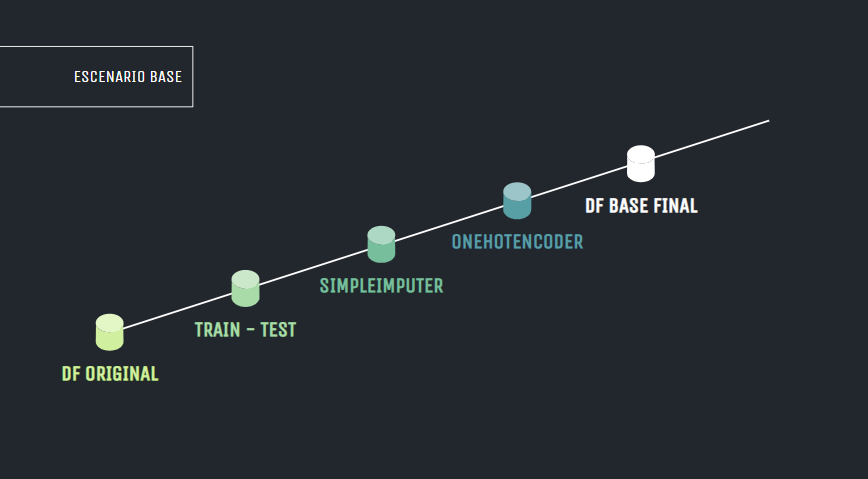

In [12]:
#--Escenario Base--

# 1) Separar la variable target
df_escBase = df.copy()
X_escBase = df_escBase.drop(['consumo','consumo_cat'], axis=1)
y_escBase = df_escBase['consumo_cat']

# 2) Dividir el set de datos de entrenamiento y testeo (70-30)
X_train_escBase, X_test_escBase, y_train_escBase, y_test_escBase = train_test_split(X_escBase, y_escBase, test_size=0.3, random_state=42)

# 3) Imputacion y Encoding
  # Identificar columnas numéricas y categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = X_train_escBase.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
categorical_cols = X_train_escBase.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar las transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación y las categorías para el encoding) y transforma los datos
X_train_processed = preprocessor.fit_transform(X_train_escBase)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
X_test_processed = preprocessor.transform(X_test_escBase)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requiere reconstruir los nombres de las columnas después de la transformación
  # Primero, obtener los nombres de las columnas transformadas
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, añadir las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in X_train_escBase.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
X_train_final_escBase = pd.DataFrame(X_train_processed, index=X_train_escBase.index, columns=all_feature_names)
X_test_final_escBase = pd.DataFrame(X_test_processed, index=X_test_escBase.index, columns=all_feature_names)


  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
y_train_final_escBase = y_train_escBase
y_test_final_escBase = y_test_escBase


print("Preparación de datos para Escenario Base completa usando pipeline.")
print(f"X_train_final_escBase shape: {X_train_final_escBase.shape}")
print(f"X_test_final_escBase shape: {X_test_final_escBase.shape}")
print(f"y_train_final_escBase shape: {y_train_final_escBase.shape}")
print(f"y_test_final_escBase shape: {y_test_final_escBase.shape}")

print("\nX_train_final_escBase head:")
display(X_train_final_escBase.head())

print("\nX_test_final_escBase head:")
display(X_test_final_escBase.head())


Preparación de datos para Escenario Base completa usando pipeline.
X_train_final_escBase shape: (53029, 128)
X_test_final_escBase shape: (22728, 128)
y_train_final_escBase shape: (53029,)
y_test_final_escBase shape: (22728,)

X_train_final_escBase head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,6.0,8054.69,1959.0,61.0,198.1,-18.89,-3.80,10.00,-16.67,-1.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,2.0,53405.94,1990.0,86.0,15.2,-10.56,2.96,16.67,-6.67,4.93,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,6.0,6521.79,1979.0,9.0,26.5,-2.22,6.36,13.33,1.11,8.71,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,1.0,263652.40,1970.0,70.0,42.7,-14.44,-1.29,11.67,-9.44,2.24,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,5.0,5384.66,1928.0,54.0,25.6,-13.33,-1.19,13.33,-16.67,-4.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_escBase head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,3.0,23674.38,1990.0,61.09609,15.2,-11.67,1.71,16.11,-8.33,1.06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,6.0,6362.00,1928.0,97.00000,3.4,-11.67,1.36,15.00,-18.33,3.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,6.0,9636.27,1941.0,65.00000,10.7,-11.67,1.36,15.00,-18.33,3.17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,5.0,21547.74,1957.0,78.00000,21.3,-13.33,-1.19,13.33,-16.67,-4.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,6.0,1211.46,1931.0,86.00000,2.4,2.78,11.50,16.67,5.56,13.86,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 1

DESCRIPCION:

* Datos escalados con 'StandardScaler'.
* Todas las features.
* Imputacion de valores faltantes mediante 'SimpleImputer'
* Encoding de variables categoricas mediante 'OneHotEncoder'

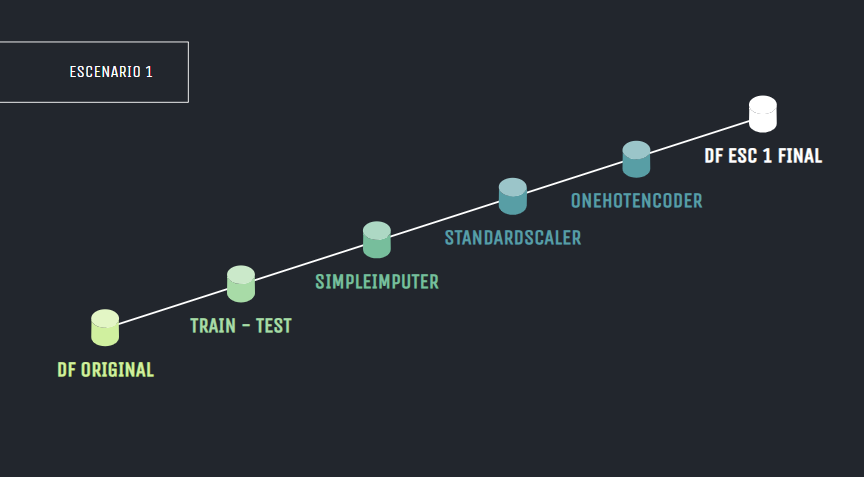

In [5]:
#--Escenario 1--

# 1) Separar la variable target
df_esc1 = df.copy()
X_esc1 = df_esc1.drop(['consumo','consumo_cat'], axis=1)
y_esc1 = df_esc1['consumo_cat']

# 2) Dividir el set de datos de entrenamiento y testeo (70-30)
X_train_esc1, X_test_esc1, y_train_esc1, y_test_esc1 = train_test_split(X_esc1, y_esc1, test_size=0.3, random_state=42)

# 3) Imputacion, Escalado y Encoding
  # Identificar columnas numéricas y categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = X_train_esc1.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
categorical_cols = X_train_esc1.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación y Escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar las transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación, la media y desviación estándar para el escalado y las categorías para el encoding) y transforma los datos
X_train_processed = preprocessor.fit_transform(X_train_esc1)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
X_test_processed = preprocessor.transform(X_test_esc1)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requiere reconstruir los nombres de las columnas después de la transformación
  # Primero, obtener los nombres de las columnas transformadas
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, añadir las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in X_train_esc1.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
X_train_final_esc1 = pd.DataFrame(X_train_processed, index=X_train_esc1.index, columns=all_feature_names)
X_test_final_esc1 = pd.DataFrame(X_test_processed, index=X_test_esc1.index, columns=all_feature_names)


  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
y_train_final_esc1 = y_train_esc1
y_test_final_esc1 = y_test_esc1


print("Preparación de datos para Escenario 1 completa usando pipeline.")
print(f"X_train_final_esc1 shape: {X_train_final_esc1.shape}")
print(f"X_test_final_esc1 shape: {X_test_final_esc1.shape}")
print(f"y_train_final_esc1 shape: {y_train_final_esc1.shape}")
print(f"y_test_final_esc1 shape: {y_test_final_esc1.shape}")

print("\nX_train_final_esc1 head:")
display(X_train_final_esc1.head())

print("\nX_test_final_esc1 head:")
display(X_test_final_esc1.head())

Preparación de datos para Escenario 1 completa usando pipeline.
X_train_final_esc1 shape: (53029, 128)
X_test_final_esc1 shape: (22728, 128)
y_train_final_esc1 shape: (53029,)
y_test_final_esc1 shape: (22728,)

X_train_final_esc1 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,1.108561,-0.326554,0.182698,-0.004180,2.659445,-1.432769,-1.309383,-1.690125,-0.773749,-0.654066,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034244,1.083317,-0.406136,0.164327,0.429344,0.551052,0.655523,0.601565,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732082,-2.266174,-0.216737,1.763341,1.303852,-0.571217,1.767496,1.367094,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.484859,0.387319,0.054790,-0.579578,-0.663790,-1.128991,0.259614,0.056783,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668849,-0.308679,-0.231822,-0.366760,-0.638069,-0.571217,-0.773749,-1.302133,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_esc1 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_promedio,enero_temp_max,febrero_temp_min,febrero_temp_promedio,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,-0.926445,0.368346,1.034244,-3.090853e-16,-0.406136,-0.048491,0.107834,0.362887,0.418264,-0.182192,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,1.108561,-0.401859,-0.668849,1.561816e+00,-0.603916,-0.048491,0.017811,-0.010082,-1.011009,0.245128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311749,1.698196e-01,-0.481561,-0.048491,0.017811,-0.010082,-1.011009,0.245128,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127759,7.353182e-01,-0.303894,-0.366760,-0.638069,-0.571217,-0.773749,-1.302133,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586441,1.083317e+00,-0.620677,2.721982,2.625902,0.551052,2.403522,2.410078,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 2

**Escenerio conservador** donde se tienen en cuenta no solo todas las variables
que se consideran relevantes sino tambien algunas adicionales, no se eliminan registros, se imputan datos faltantes.

DESCRIPCION:

* Datos escalados con _'StandardScaler'_.
* Imputcion de valores faltantes:
  * Se hace la imputacion en las variables 'año_construccion' (por su bajo porcentaje de valor faltantes, **2,4%**) y 'calificacion_energystar' (por su importancia para predecir la variable target, **-0,51 de correlacion**).
* Variables categoricas:
  * Eliminacion de 'clase_edificio', la informacion esta contemplada en 'tipo_instalacion'.
  * La variable 'tipo_instalacion' se agrupa en los siguientes rubros:
    * Residential: 57.16%
    * Office: 17.36%
    * Education: 7.57%
    * Warehouse/Industrial: 4.30%
    * Service: 3.29%
    * Retail: 2.58%
    * Other/Unknown: 2.56%
    * Public Assembly: 2.16%
    * Health Care: 1.74%
    * Mixed Use: 1.23%
   
  * Codificadas con metodo _'OneHotEncoder'_
* Variables de temperatura por mes:
  * Eliminacion de todas las 'nombreMes_temp_promedio', se conservan solo los minimos y maximos de cada mes, con esta informacion ya se esta contemplando el promedio.
* Variables meteorologicas:
  * Eliminacion de las 3 variables asociadas al viento ('direccion_velocidad_viento_maxima', 'direccion_velocidad_viento_pico' y 'velocidad_viento_maxima') y la de niebla ('dias_con_niebla'), por el gran procentaje de valores faltantes, **>50%**.


  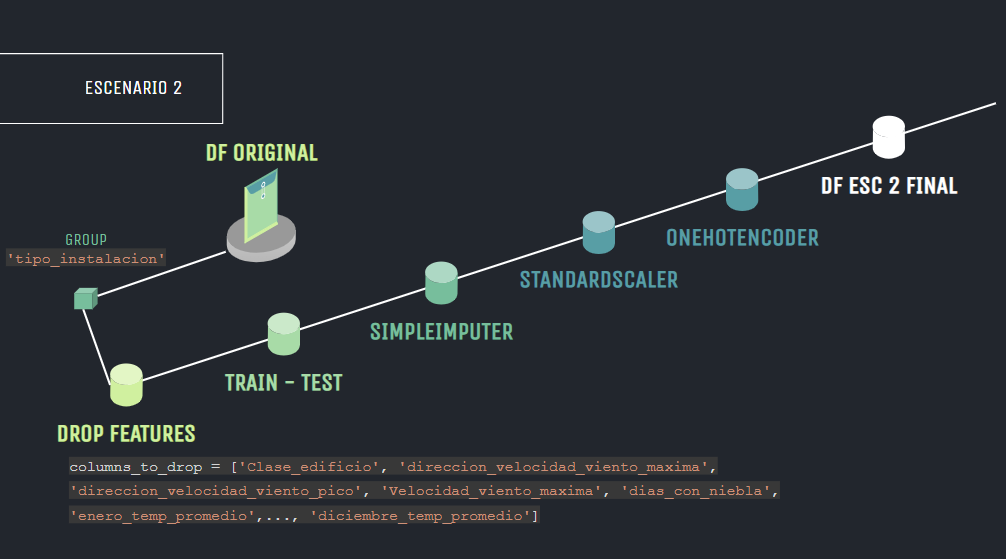

In [7]:
#--Escenario 2--

# Define a mapping from detailed facility types to broader categories
facility_type_mapping = {
    '5plus_Unit_Building': 'Residential',
    'Multifamily_Uncategorized': 'Residential',
    '2to4_Unit_Building': 'Residential',
    'Lodging_Dormitory_or_fraternity_sorority': 'Residential',
    'Office_Uncategorized': 'Office',
    'Office_Medical_non_diagnostic': 'Office',
    'Office_Bank_or_other_financial': 'Office',
    'Office_Mixed_use': 'Office',
    'Retail_Enclosed_mall': 'Retail',
    'Retail_Vehicle_dealership_showroom': 'Retail',
    'Retail_Uncategorized': 'Retail',
    'Retail_Strip_shopping_mall': 'Retail',
    'Food_Sales': 'Retail',
    'Grocery_store_or_food_market': 'Retail',
    'Warehouse_Distribution_or_Shipping_center': 'Warehouse/Industrial',
    'Warehouse_Nonrefrigerated': 'Warehouse/Industrial',
    'Warehouse_Selfstorage': 'Warehouse/Industrial',
    'Industrial': 'Warehouse/Industrial',
    'Warehouse_Refrigerated': 'Warehouse/Industrial',
    'Warehouse_Uncategorized': 'Warehouse/Industrial',
    'Education_Other_classroom': 'Education',
    'Education_College_or_university': 'Education',
    'Education_Uncategorized': 'Education',
    'Education_Preschool_or_daycare': 'Education',
    'Public_Assembly_Entertainment_culture': 'Public Assembly',
    'Public_Assembly_Drama_theater': 'Public Assembly',
    'Public_Assembly_Social_meeting': 'Public Assembly',
    'Religious_worship': 'Public Assembly',
    'Parking_Garage': 'Public Assembly',
    'Public_Assembly_Recreation': 'Public Assembly',
    'Public_Assembly_Movie_Theater': 'Public Assembly',
    'Public_Assembly_Uncategorized': 'Public Assembly',
    'Public_Assembly_Library': 'Public Assembly',
    'Public_Safety_Uncategorized': 'Public Assembly',
    'Public_Safety_Fire_or_police_station': 'Public Assembly',
    'Public_Assembly_Other': 'Public Assembly',
    'Public_Safety_Penitentiary': 'Public Assembly',
    'Public_Safety_Courthouse': 'Public Assembly',
    'Public_Assembly_Stadium': 'Public Assembly',
    'Health_Care_Inpatient': 'Health Care',
    'Health_Care_Uncategorized': 'Health Care',
    'Health_Care_Outpatient_Clinic': 'Health Care',
    'Health_Care_Outpatient_Uncategorized': 'Health Care',
    'Nursing_Home': 'Health Care',
    'Service_Vehicle_service_repair_shop': 'Service',
    'Service_Drycleaning_or_Laundry': 'Service',
    'Service_Uncategorized': 'Service',
    'Food_Service_Uncategorized': 'Service',
    'Food_Service_Other': 'Service',
    'Food_Service_Restaurant_or_cafeteria': 'Service',
    'Lodging_Hotel': 'Service', # Could also be Lodging, but grouping with service for simplicity
    'Lodging_Other': 'Service',
    'Lodging_Uncategorized': 'Service',
    'Mixed_Use_Predominantly_Commercial': 'Mixed Use',
    'Mixed_Use_Commercial_and_Residential': 'Mixed Use',
    'Mixed_Use_Predominantly_Residential': 'Mixed Use',
    'Commercial_Other': 'Other/Unknown',
    'Commercial_Unknown': 'Other/Unknown',
    'Laboratory': 'Other/Unknown' # Assuming Laboratory is not a major category
}

# 1) Copia del dataframe original
df_esc2 = df.copy()

# Apply the mapping to create a new grouped column
df_esc2['tipo_instalacion_agrupado'] = df_esc2['tipo_instalacion'].map(facility_type_mapping)


# Apply eliminaciones y selecciones ANTES de separar X e y
# Eliminar columnas especificadas, including the original 'tipo_instalacion'
columns_to_drop = [
    'clase_edificio',
    'direccion_velocidad_viento_maxima',
    'direccion_velocidad_viento_pico',
    'velocidad_viento_maxima',
    'dias_con_niebla',
    'enero_temp_promedio', 'febrero_temp_promedio', 'marzo_temp_promedio',
    'abril_temp_promedio', 'mayo_temp_promedio', 'junio_temp_promedio',
    'julio_temp_promedio', 'agosto_temp_promedio', 'septiembre_temp_promedio',
    'octubre_temp_promedio', 'noviembre_temp_promedio', 'diciembre_temp_promedio',
    'tipo_instalacion' # Add the original column to drop
]
df_esc2 = df_esc2.drop(columns=columns_to_drop, errors='ignore') # Use errors='ignore' to avoid errors if a column is already dropped or not present

# 2) Separar la variable target
X_esc2 = df_esc2.drop(['consumo','consumo_cat'], axis=1)
y_esc2 = df_esc2['consumo_cat']

# 3) Dividir el set de datos de entrenamiento y testeo (70-30)
X_train_esc2, X_test_esc2, y_train_esc2, y_test_esc2 = train_test_split(X_esc2, y_esc2, test_size=0.3, random_state=42)

# 3) Imputacion, Escalado y Encoding
  # Identificar columnas numéricas and categóricas DESPUÉS del split
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = X_train_esc2.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
# Update categorical_cols to include the new grouped column
categorical_cols = X_train_esc2.select_dtypes(include=['object', 'category']).columns.tolist()


  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Imputación y Escalado
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Use mean imputation for all numerical columns
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Apply the numerical pipeline to all identified numerical columns
  # Apply the categorical pipeline to all identified categorical columns
  # 'remainder'='passthrough' will keep the unspecified columns (like 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols), # Apply numerical pipeline to all numerical columns
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)


  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros del preprocesamiento (como la media para la imputación, la media y desviación estándar para el escalado y las categorías para el encoding) y transforma los datos
X_train_processed = preprocessor.fit_transform(X_train_esc2)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos en el conjunto de entrenamiento para transformar los datos de prueba
X_test_processed = preprocessor.transform(X_test_esc2)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Esto requires reconstructing the column names after the transformation
  # First, get the names of the transformed columns from the numerical pipeline
transformed_cols = numerical_cols
  # Add the names from the one-hot encoder
transformed_cols += list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Then, add the columns that passed directly ('remainder')
passthrough_cols = [col for col in X_train_esc2.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 4) Generar los Dataframe para lo modelos
  # Convertir los arrays procesados de vuelta a DataFrames
X_train_final_esc2 = pd.DataFrame(X_train_processed, index=X_train_esc2.index, columns=all_feature_names)
X_test_final_esc2 = pd.DataFrame(X_test_processed, index=X_test_esc2.index, columns=all_feature_names)


  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
y_train_final_esc2 = y_train_esc2
y_test_final_esc2 = y_test_esc2


print("Preparación de datos para Escenario 2 completa usando pipeline.")
print(f"X_train_final_esc2 shape: {X_train_final_esc2.shape}")
print(f"X_test_final_esc2 shape: {X_test_final_esc2.shape}")
print(f"y_train_final_esc2 shape: {y_train_final_esc2.shape}")
print(f"y_test_final_esc2 shape: {y_test_final_esc2.shape}")

print("\nX_train_final_esc2 head:")
display(X_train_final_esc2.head())

print("\nX_test_final_esc2 head:")
display(X_test_final_esc2.head())

Preparación de datos para Escenario 2 completa usando pipeline.
X_train_final_esc2 shape: (53029, 61)
X_test_final_esc2 shape: (22728, 61)
y_train_final_esc2 shape: (53029,)
y_test_final_esc2 shape: (22728,)

X_train_final_esc2 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_max,febrero_temp_min,febrero_temp_max,marzo_temp_min,...,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial,tipo_instalacion_agrupado_nan
13184,1.108561,-0.326554,0.182698,-0.004180,2.659445,-1.432769,-1.690125,-0.773749,0.773166,-0.959667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034244,1.083317,-0.406136,0.164327,0.551052,0.655523,0.419016,0.337433,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732082,-2.266174,-0.216737,1.763341,-0.571217,1.767496,0.655827,1.336309,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.484859,0.387319,0.054790,-0.579578,-1.128991,0.259614,1.009976,-0.162004,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668849,-0.308679,-0.231822,-0.366760,-0.571217,-0.773749,-1.833885,-0.959667,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0



X_test_final_esc2 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_min,enero_temp_max,febrero_temp_min,febrero_temp_max,marzo_temp_min,...,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial,tipo_instalacion_agrupado_nan
29922,-0.926445,0.368346,1.034244,-3.090853e-16,-0.406136,-0.048491,0.362887,0.418264,-0.410887,0.536849,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
55120,1.108561,-0.401859,-0.668849,1.561816e+00,-0.603916,-0.048491,-0.010082,-1.011009,0.299544,0.438040,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311749,1.698196e-01,-0.481561,-0.048491,-0.010082,-1.011009,0.299544,0.438040,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127759,7.353182e-01,-0.303894,-0.366760,-0.571217,-0.773749,-1.833885,-0.959667,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586441,1.083317e+00,-0.620677,2.721982,0.551052,2.403522,1.959352,2.532803,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## ESCENARIO 3

**Escenerio arriesgado** donde solo se tienen en cuenta las variables que se consideran relevantes, se eliminan registros que se consideran que pueden afectar al modelo, no se imputan datos faltantes para no agregar informacion estimada al data set.

DESCRIPCION:

* Datos escalados con _'StandardScaler'_.
* Valores faltantes:
  * En aquellas variables que contengan datos faltantes, se elimina directamente el registro, para no introducir error en el set de datos.
* Variables categoricas:
  * Eliminacion de 'clase_edificio', la informacion esta contemplada en 'tipo_instalacion'.
  * La variable 'tipo_instalacion' se agrupa en los siguientes rubros:
      * Residential: 57.16%
      * Office: 17.36%
      * Education: 7.57%
      * Warehouse/Industrial: 4.30%
      * Service: 3.29%
      * Retail: 2.58%
      * Other/Unknown: 2.56%
      * Public Assembly: 2.16%
      * Health Care: 1.74%
      * Mixed Use: 1.23%
* Variables de temperatura:
  * Solo se considera 'temperatura_promedio'.
* Variables meteorologicas:
  * Eliminacion de las 3 variables asociadas al viento ('direccion_velocidad_viento_maxima', 'direccion_velocidad_viento_pico' y 'velocidad_viento_maxima') y la de niebla ('dias_con_niebla'), por el gran procentaje de valores faltantes, **>50%**.


  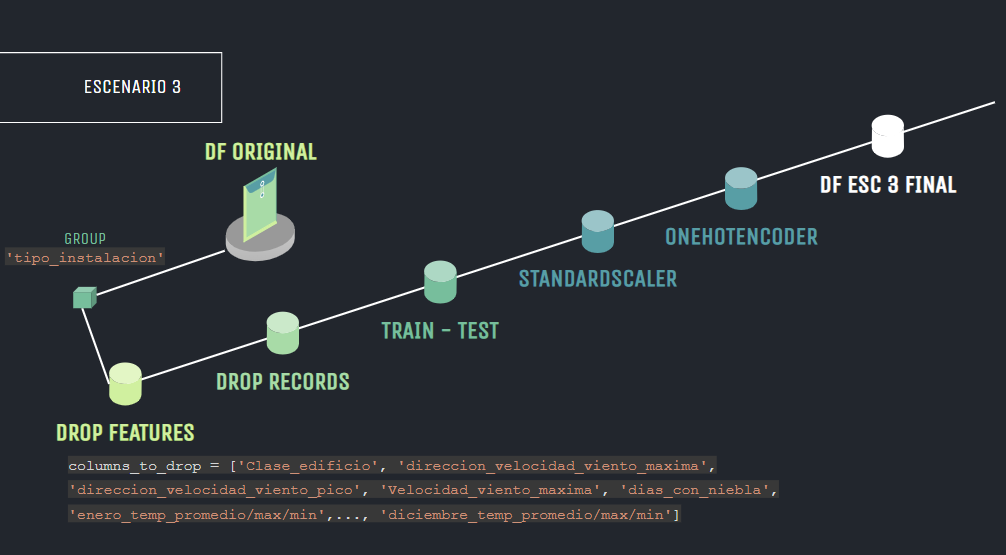

In [8]:
#--Escenario 3--

# Define a mapping from detailed facility types to broader categories
facility_type_mapping = {
    '5plus_Unit_Building': 'Residential',
    'Multifamily_Uncategorized': 'Residential',
    '2to4_Unit_Building': 'Residential',
    'Lodging_Dormitory_or_fraternity_sorority': 'Residential',
    'Office_Uncategorized': 'Office',
    'Office_Medical_non_diagnostic': 'Office',
    'Office_Bank_or_other_financial': 'Office',
    'Office_Mixed_use': 'Office',
    'Retail_Enclosed_mall': 'Retail',
    'Retail_Vehicle_dealership_showroom': 'Retail',
    'Retail_Uncategorized': 'Retail',
    'Retail_Strip_shopping_mall': 'Retail',
    'Food_Sales': 'Retail',
    'Grocery_store_or_food_market': 'Retail',
    'Warehouse_Distribution_or_Shipping_center': 'Warehouse/Industrial',
    'Warehouse_Nonrefrigerated': 'Warehouse/Industrial',
    'Warehouse_Selfstorage': 'Warehouse/Industrial',
    'Industrial': 'Warehouse/Industrial',
    'Warehouse_Refrigerated': 'Warehouse/Industrial',
    'Warehouse_Uncategorized': 'Warehouse/Industrial',
    'Education_Other_classroom': 'Education',
    'Education_College_or_university': 'Education',
    'Education_Uncategorized': 'Education',
    'Education_Preschool_or_daycare': 'Education',
    'Public_Assembly_Entertainment_culture': 'Public Assembly',
    'Public_Assembly_Drama_theater': 'Public Assembly',
    'Public_Assembly_Social_meeting': 'Public Assembly',
    'Religious_worship': 'Public Assembly',
    'Parking_Garage': 'Public Assembly',
    'Public_Assembly_Recreation': 'Public Assembly',
    'Public_Assembly_Movie_Theater': 'Public Assembly',
    'Public_Assembly_Uncategorized': 'Public Assembly',
    'Public_Assembly_Library': 'Public Assembly',
    'Public_Safety_Uncategorized': 'Public Assembly',
    'Public_Safety_Fire_or_police_station': 'Public Assembly',
    'Public_Assembly_Other': 'Public Assembly',
    'Public_Safety_Penitentiary': 'Public Assembly',
    'Public_Safety_Courthouse': 'Public Assembly',
    'Public_Assembly_Stadium': 'Public Assembly',
    'Health_Care_Inpatient': 'Health Care',
    'Health_Care_Uncategorized': 'Health Care',
    'Health_Care_Outpatient_Clinic': 'Health Care',
    'Health_Care_Outpatient_Uncategorized': 'Health Care',
    'Nursing_Home': 'Health Care',
    'Service_Vehicle_service_repair_shop': 'Service',
    'Service_Drycleaning_or_Laundry': 'Service',
    'Service_Uncategorized': 'Service',
    'Food_Service_Uncategorized': 'Service',
    'Food_Service_Other': 'Service',
    'Food_Service_Restaurant_or_cafeteria': 'Service',
    'Lodging_Hotel': 'Service', # Could also be Lodging, but grouping with service for simplicity
    'Lodging_Other': 'Service',
    'Lodging_Uncategorized': 'Service',
    'Mixed_Use_Predominantly_Commercial': 'Mixed Use',
    'Mixed_Use_Commercial_and_Residential': 'Mixed Use',
    'Mixed_Use_Predominantly_Residential': 'Mixed Use',
    'Commercial_Other': 'Other/Unknown',
    'Commercial_Unknown': 'Other/Unknown',
    'Laboratory': 'Other/Unknown' # Assuming Laboratory is not a major category
}

# 1) Copia del dataframe original
df_esc3 = df.copy()

# Apply the mapping to create a new grouped column
df_esc3['tipo_instalacion_agrupado'] = df_esc3['tipo_instalacion'].map(facility_type_mapping)

# Aplicar eliminaciones iniciales de columnas según descripción, including original 'tipo_instalacion'
columns_to_drop_initial = [
    'clase_edificio',
    'direccion_velocidad_viento_maxima',
    'direccion_velocidad_viento_pico',
    'velocidad_viento_maxima',
    'dias_con_niebla',
    'tipo_instalacion' # Add original column to drop
]
df_esc3 = df_esc3.drop(columns=columns_to_drop_initial, errors='ignore')

# Seleccionar solo 'temperatura_promedio' de las columnas de temperatura
temp_cols = [col for col in df_esc3.columns if 'temp' in col]
temp_cols_to_drop = [col for col in temp_cols if col != 'temperatura_promedio']
df_esc3 = df_esc3.drop(columns=temp_cols_to_drop, errors='ignore')

# Eliminar filas con valores faltantes
df_esc3.dropna(inplace=True)

# 2) Separar la variable target
X_esc3 = df_esc3.drop(['consumo','consumo_cat'], axis=1)
y_esc3 = df_esc3['consumo_cat']

# 3) Dividir el set de datos de entrenamiento y testeo (70-30)
X_train_esc3, X_test_esc3, y_train_esc3, y_test_esc3 = train_test_split(X_esc3, y_esc3, test_size=0.3, random_state=42)

# 4) Escalado y Codificación
  # Identificar columnas numéricas y categóricas DESPUÉS de eliminar NaNs y dividir
  # Excluir 'id' de las columnas numéricas que serán transformadas si existe
numerical_cols = X_train_esc3.select_dtypes(include=np.number).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
# Update categorical_cols to include the new grouped column
categorical_cols = X_train_esc3.select_dtypes(include=['object', 'category']).columns.tolist()

  # Crear preprocesadores para columnas numéricas y categóricas
  # Pipeline numérico: Escalado
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
    ])

  # Pipeline categórico: Codificación One-Hot
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

  # Combinar preprocesadores usando ColumnTransformer
  # Aplicar transformaciones a las columnas numéricas y categóricas identificadas
  # 'remainder'='passthrough' mantendrá las columnas no especificadas (como 'id')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)

  # Aplicar el preprocesador al conjunto de entrenamiento
  # fit_transform aprende los parámetros de preprocesamiento y transforma los datos
X_train_processed = preprocessor.fit_transform(X_train_esc3)

  # Aplicar el preprocesador al conjunto de prueba
  # transform usa los parámetros aprendidos del conjunto de entrenamiento
X_test_processed = preprocessor.transform(X_test_esc3)

  # Obtener nombres de características después del preprocesamiento para crear DataFrames
  # Reconstruir nombres de columnas después de la transformación
  # Primero, obtener nombres de columnas transformadas del pipeline numérico
transformed_cols = numerical_cols
  # Agregar nombres del codificador one-hot
transformed_cols += list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
  # Luego, agregar las columnas que pasaron directamente ('remainder')
passthrough_cols = [col for col in X_train_esc3.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# 5) Generar DataFrames para los modelos
  # Convertir los arrays procesados de vuelta a DataFrames
X_train_final_esc3 = pd.DataFrame(X_train_processed, index=X_train_esc3.index, columns=all_feature_names)
X_test_final_esc3 = pd.DataFrame(X_test_processed, index=X_test_esc3.index, columns=all_feature_names)


  # Los dataframes y ya están divididos y no necesitan más procesamiento para este escenario
y_train_final_esc3 = y_train_esc3
y_test_final_esc3 = y_test_esc3


print("Preparación de datos para Escenario 3 completa usando pipeline.")
print(f"X_train_final_esc3 shape: {X_train_final_esc3.shape}")
print(f"X_test_final_esc3 shape: {X_test_final_esc3.shape}")
print(f"y_train_final_esc3 shape: {y_train_final_esc3.shape}")
print(f"y_test_final_esc3 shape: {y_test_final_esc3.shape}")

print("\nX_train_final_esc3 head:")
display(X_train_final_esc3.head())

print("\nX_test_final_esc3 head:")
display(X_test_final_esc3.head())

Preparación de datos para Escenario 3 completa usando pipeline.
X_train_final_esc3 shape: (33905, 35)
X_test_final_esc3 shape: (14531, 35)
y_train_final_esc3 shape: (33905,)
y_test_final_esc3 shape: (14531,)

X_train_final_esc3 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_agrupado_Education,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial
66712,-0.655464,2.345326,1.346182,0.558221,0.933717,0.564613,0.289031,0.569796,0.552846,-0.441244,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3332,-0.655464,-0.574636,-0.341536,0.208885,-0.577889,-1.695023,-3.544400,-2.130728,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
16045,-3.042265,0.515004,-0.673966,0.208885,0.012692,0.309803,-0.051909,2.872874,0.698111,1.207572,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2033,-1.451064,-0.646742,-0.929681,0.977425,-0.577889,-2.161374,-1.551309,-3.717635,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
58499,0.935737,-0.565264,-0.648394,0.558221,0.012692,0.689614,-0.153335,-0.068614,0.212034,-0.540504,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_esc3 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_agrupado_Education,tipo_instalacion_agrupado_Health Care,tipo_instalacion_agrupado_Mixed Use,tipo_instalacion_agrupado_Office,tipo_instalacion_agrupado_Other/Unknown,tipo_instalacion_agrupado_Public Assembly,tipo_instalacion_agrupado_Residential,tipo_instalacion_agrupado_Retail,tipo_instalacion_agrupado_Service,tipo_instalacion_agrupado_Warehouse/Industrial
54238,0.935737,-0.415633,-0.443822,-1.502863,-0.678077,0.689614,-0.153335,-0.068614,0.212034,-0.540504,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
36820,-0.655464,-0.241566,0.144322,0.697956,0.012692,-0.178182,0.607974,1.046924,0.994226,0.981480,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
51176,0.140136,-0.440879,-0.750680,-2.026868,-0.470671,0.910770,0.100842,-0.183816,0.943942,1.455722,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2064,-1.451064,-0.638945,-1.313253,1.221960,-0.577889,-2.161374,-1.551309,-3.717635,-1.799317,-1.097462,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9552,0.935737,0.767691,0.988181,1.047292,-0.685108,0.884328,-0.292644,-0.553422,-0.123191,-0.755567,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print("Columnas en el DataFrame de Escenario 3:")
print(X_train_final_esc3.columns.tolist())

Columnas en el DataFrame de Escenario 3:
['factor_año', 'area_edificio', 'año_construccion', 'calificacion_energystar', 'elevacion', 'grados_dia_enfriamiento', 'grados_dia_calefaccion', 'precipitacion_mm', 'nevada_mm', 'profundidad_nieve_mm', 'dias_menos_1C', 'dias_menos_6C', 'dias_menos_12C', 'dias_menos_18C', 'dias_mas_27C', 'dias_mas_32C', 'dias_mas_38C', 'dias_mas_43C', 'factor_estado_State_1', 'factor_estado_State_10', 'factor_estado_State_11', 'factor_estado_State_2', 'factor_estado_State_4', 'factor_estado_State_6', 'factor_estado_State_8', 'tipo_instalacion_agrupado_Education', 'tipo_instalacion_agrupado_Health Care', 'tipo_instalacion_agrupado_Mixed Use', 'tipo_instalacion_agrupado_Office', 'tipo_instalacion_agrupado_Other/Unknown', 'tipo_instalacion_agrupado_Public Assembly', 'tipo_instalacion_agrupado_Residential', 'tipo_instalacion_agrupado_Retail', 'tipo_instalacion_agrupado_Service', 'tipo_instalacion_agrupado_Warehouse/Industrial']


## ESCENARIO 4

DESCRIPCION:

+ Eliminación de las variables climaticas
 + Variables relacionadas a viento y niebla
 + Variables de rango de temperatura, quitando minimo y maximo para solo conservar promedio por mes
+ Se descarta la variable "tipo de instalación" preeviendo que su informacion este correctamtente representada en la variables "clase de edificio"
+ La implementacion de un pipeline que impute los datos faltantes con "_IterativeImputer_" con un máximo de 100 iteraciones y luego escale los datos con "_StandardScaler_".

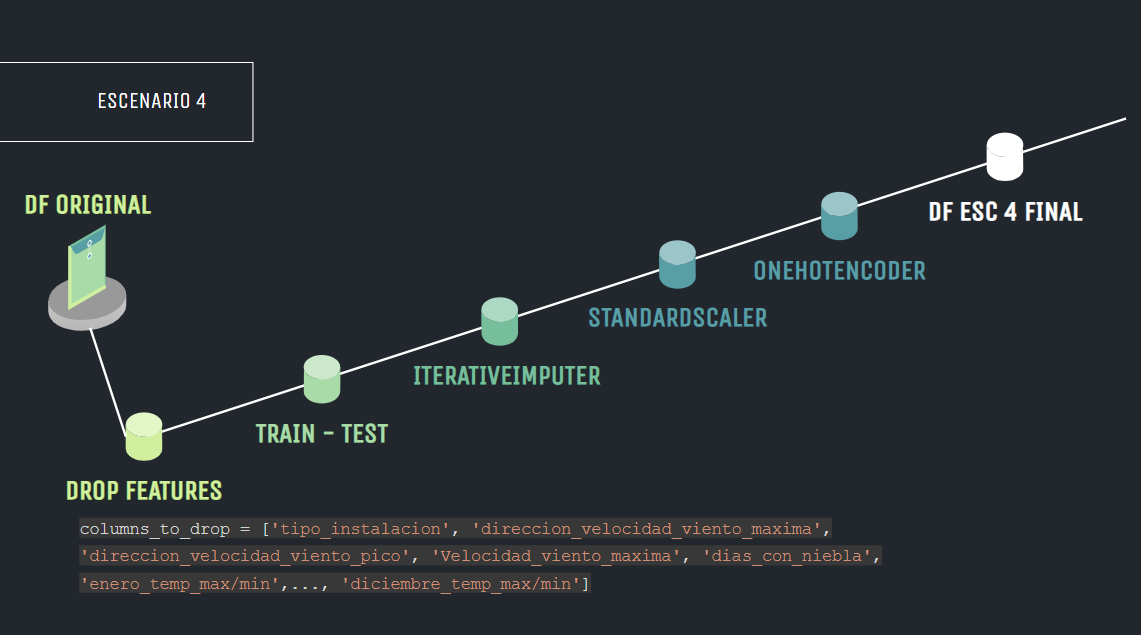

In [9]:
# Step 0: Copy df
df_esc4 = df.copy()

# Step 1: Drop unwanted columns
temp_cols_to_drop = [col for col in df_esc4.columns if ('_temp_min' in col or '_temp_max' in col)]
wind_fog_cols_to_drop = [col for col in df_esc4.columns if ('viento' in col or 'niebla' in col)]

df_esc4 = df_esc4.drop(columns=temp_cols_to_drop + wind_fog_cols_to_drop + ['tipo_instalacion'], errors='ignore')

# Step 2: Separate target
X_esc4 = df_esc4.drop(['consumo','consumo_cat'], axis=1)
y_esc4 = df_esc4['consumo_cat']

# Step 3: Train/test split before anything else
X_train_esc4, X_test_esc4, y_train_esc4, y_test_esc4= train_test_split(
    X_esc4, y_esc4, test_size=0.3, random_state=42
)

# Step 4: Separate column types AFTER the split
numerical_cols = X_train_esc4.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_esc4.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 5: Create preprocessors for numerical and categorical columns
# Numerical pipeline: Impute + Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', IterativeImputer(max_iter=100, random_state=0)),
    ('scaler', StandardScaler())
])

# Categorical pipeline: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)

# Step 6: Apply the preprocessor to the training and test sets
X_train_processed = preprocessor.fit_transform(X_train_esc4)
X_test_processed = preprocessor.transform(X_test_esc4)

# Step 7: Get feature names after preprocessing to create DataFrames
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
passthrough_cols = [col for col in X_train_esc4.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols

# Step 8: Generate DataFrames for the models
X_train_final_esc4 = pd.DataFrame(X_train_processed, index=X_train_esc4.index, columns=all_feature_names)
X_test_final_esc4 = pd.DataFrame(X_test_processed, index=X_test_esc4.index, columns=all_feature_names)

# Assign target variables to match scenario naming convention
y_train_final_esc4 = y_train_esc4
y_test_final_esc4 = y_test_esc4

# Optional: check the shape
print("Preparación de datos para Escenario 4 completa usando pipeline.")
print(f"X_train_final_esc4 shape: {X_train_final_esc4.shape}")
print(f"X_test_final_esc4 shape: {X_test_final_esc4.shape}")
print(f"y_train_final_esc4 shape: {y_train_final_esc4.shape}")
print(f"y_test_final_esc4 shape: {y_test_final_esc4.shape}")

print("\nX_train_final_esc4 head:")
display(X_train_final_esc4.head())

print("\nX_test_final_esc4 head:")
display(X_test_final_esc4.head())

Preparación de datos para Escenario 4 completa usando pipeline.
X_train_final_esc4 shape: (53029, 40)
X_test_final_esc4 shape: (22728, 40)
y_train_final_esc4 shape: (53029,)
y_test_final_esc4 shape: (22728,)

X_train_final_esc4 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_promedio,febrero_temp_promedio,marzo_temp_promedio,abril_temp_promedio,mayo_temp_promedio,...,dias_mas_43C,factor_estado_State_1,factor_estado_State_10,factor_estado_State_11,factor_estado_State_2,factor_estado_State_4,factor_estado_State_6,factor_estado_State_8,clase_edificio_Commercial,clase_edificio_Residential
13184,1.108561,-0.326554,0.192088,-0.022854,2.659445,-1.309383,-0.654066,0.003433,-1.909878,-0.647002,...,-0.015699,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
18163,-1.604780,1.691065,1.032706,1.054969,-0.406136,0.429344,0.601565,0.968587,0.391257,0.483240,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
74041,1.108561,-0.394751,0.734422,-2.264727,-0.216737,1.303852,1.367094,0.730678,0.988114,-1.623119,...,-0.015699,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
16247,-2.283115,11.044662,0.490372,0.365162,0.054790,-0.663790,0.056783,-0.326396,0.204290,0.264898,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
50301,0.430226,-0.445340,-0.648530,-0.324645,-0.231822,-0.638069,-1.302133,-0.959018,0.182717,1.703388,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0



X_test_final_esc4 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,enero_temp_promedio,febrero_temp_promedio,marzo_temp_promedio,abril_temp_promedio,mayo_temp_promedio,...,dias_mas_43C,factor_estado_State_1,factor_estado_State_10,factor_estado_State_11,factor_estado_State_2,factor_estado_State_4,factor_estado_State_6,factor_estado_State_8,clase_edificio_Commercial,clase_edificio_Residential
29922,-0.926445,0.368346,1.032706,-0.139385,-0.406136,0.107834,-0.182192,-0.650817,-0.320657,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
55120,1.108561,-0.401859,-0.648530,1.529211,-0.603916,0.017811,0.245128,0.657683,-0.184027,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
52830,1.108561,-0.256191,-0.296013,0.149597,-0.481561,0.017811,0.245128,0.657683,-0.184027,-0.338754,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
47809,0.430226,0.273735,0.137855,0.710066,-0.303894,-0.638069,-1.302133,-0.959018,0.182717,1.703388,...,-0.015699,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4663,1.108561,-0.631000,-0.567180,1.054969,-0.620677,2.625902,2.410078,1.987812,2.591718,-0.955249,...,-0.015699,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## ESCENARIO 5

DESCRIPCION:

+ Eliminación de las variables climaticas
 + Variables relacionadas a viento y niebla
 + Variables de temperatura promedio, valor minimo y valor maximo
+ Creación de una nueva variable climatica donde se promedian los meses agrupados por estacion.  
+ Nuevamente se descarta la variable "tipo de instalación" preeviendo que su informacion este correctamtente representada en la variables "clase de edificio"
+ La implementacion de un pipeline que impute los datos faltantes con "SimpleImputer" utilizando la **mediana** y luego escale los datos con "_StandardScaler_".

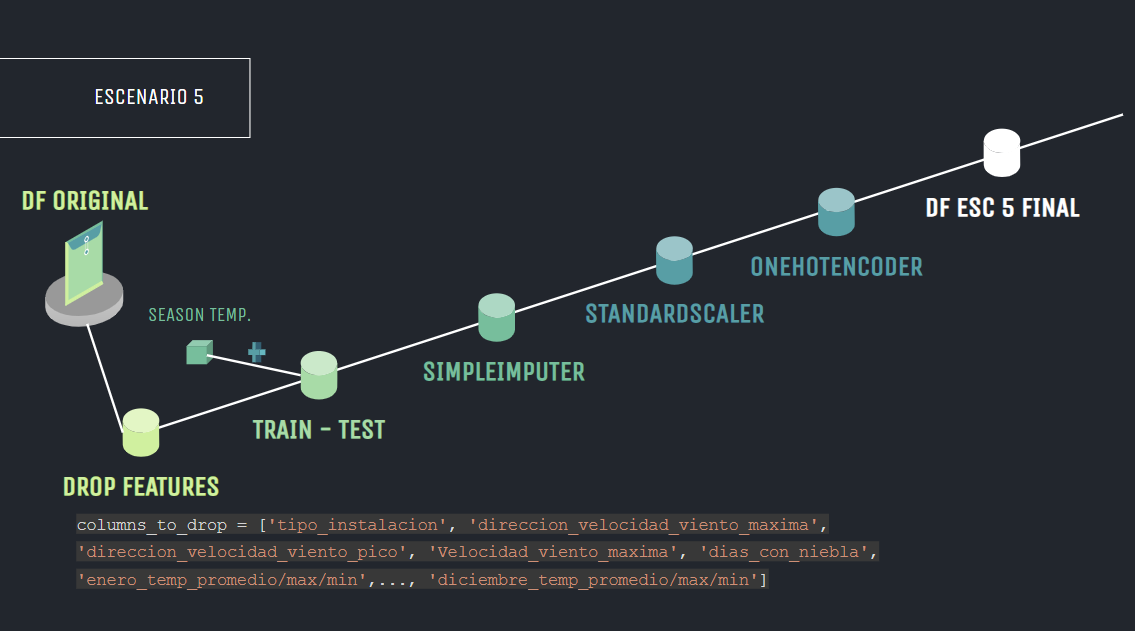

In [10]:
# Step 0: Copy base
df_esc5 = df.copy()

# Step 1: Drop unwanted columns
drop_cols = [col for col in df_esc5.columns if (
    '_temp_min' in col or '_temp_max' in col or 'viento' in col or 'niebla' in col
)]
df_esc5 = df_esc5.drop(columns=drop_cols)

# Step 2: Create seasonal average columns
seasons = {
    'verano_temp_promedio': ['junio_temp_promedio', 'julio_temp_promedio', 'agosto_temp_promedio'],
    'otoño_temp_promedio': ['septiembre_temp_promedio', 'octubre_temp_promedio', 'noviembre_temp_promedio'],
    'invierno_temp_promedio': ['diciembre_temp_promedio', 'enero_temp_promedio', 'febrero_temp_promedio'],
    'primavera_temp_promedio': ['marzo_temp_promedio', 'abril_temp_promedio', 'mayo_temp_promedio']
}

for season, months in seasons.items():
    df_esc5[season] = df_esc5[months].mean(axis=1)

# Drop monthly columns
monthly_cols = [month for months in seasons.values() for month in months]
df_esc5 = df_esc5.drop(columns=monthly_cols)


# Step 3: Split features and target
X_esc5 = df_esc5.drop(['consumo','consumo_cat'], axis=1)
y_esc5 = df_esc5['consumo_cat']

# Step 4: Train-test split (before any transformation)
X_train_esc5, X_test_esc5, y_train_esc5, y_test_esc5 = train_test_split(
    X_esc5, y_esc5, test_size=0.3, random_state=42
)

# Step 5: Identify column types
numerical_cols = X_train_esc5.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train_esc5.select_dtypes(include=['object', 'category']).columns.tolist()

# Step 6: Create preprocessors for numerical and categorical columns
# Numerical pipeline: Impute + Scale
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: One-Hot Encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough' # Keep non-specified columns
)

# Step 7: Apply the preprocessor to the training and test sets
X_train_processed = preprocessor.fit_transform(X_train_esc5)
X_test_processed = preprocessor.transform(X_test_esc5)

# Step 8: Get feature names after preprocessing to create DataFrames
transformed_cols = numerical_cols + list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols))
passthrough_cols = [col for col in X_train_esc5.columns if col not in numerical_cols + categorical_cols]
all_feature_names = transformed_cols + passthrough_cols


# Step 9: Generate DataFrames for the models
X_train_final_esc5 = pd.DataFrame(X_train_processed, index=X_train_esc5.index, columns=all_feature_names)
X_test_final_esc5 = pd.DataFrame(X_test_processed, index=X_test_esc5.index, columns=all_feature_names)

# Assign target variables to match scenario naming convention
y_train_final_esc5 = y_train_esc5
y_test_final_esc5 = y_test_esc5

# Optional: check the shape
print("Preparación de datos para Escenario 5 completa usando pipeline.")
print(f"X_train_final_esc5 shape: {X_train_final_esc5.shape}")
print(f"X_test_final_esc5 shape: {X_test_final_esc5.shape}")
print(f"y_train_final_esc5 shape: {y_train_final_esc5.shape}")
print(f"y_test_final_esc5 shape: {y_test_final_esc5.shape}")

print("\nX_train_final_esc5 head:")
display(X_train_final_esc5.head())

print("\nX_test_final_esc5 head:")
display(X_test_final_esc5.head())

Preparación de datos para Escenario 5 completa usando pipeline.
X_train_final_esc5 shape: (53029, 92)
X_test_final_esc5 shape: (22728, 92)
y_train_final_esc5 shape: (53029,)
y_test_final_esc5 shape: (22728,)

X_train_final_esc5 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
13184,1.108561,-0.326554,0.182929,-0.094671,2.659445,0.479610,1.348325,0.047848,-0.098842,-0.060235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18163,-1.604780,1.691065,1.034474,0.984705,-0.406136,0.191896,-0.419375,-0.365877,-1.092242,-0.881000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74041,1.108561,-0.394751,0.732313,-2.339773,-0.216737,-2.397529,-0.669132,0.249987,-1.552461,-0.932298,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16247,-2.283115,11.044662,0.485090,0.293904,0.054790,0.329388,0.013457,2.874022,0.877720,1.444502,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50301,0.430226,-0.445340,-0.668617,-0.396896,-0.231822,0.965923,0.165009,-0.133511,1.124667,1.700991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



X_test_final_esc5 head:


,factor_año,area_edificio,año_construccion,calificacion_energystar,elevacion,grados_dia_enfriamiento,grados_dia_calefaccion,precipitacion_mm,nevada_mm,profundidad_nieve_mm,...,tipo_instalacion_Retail_Uncategorized,tipo_instalacion_Retail_Vehicle_dealership_showroom,tipo_instalacion_Service_Drycleaning_or_Laundry,tipo_instalacion_Service_Uncategorized,tipo_instalacion_Service_Vehicle_service_repair_shop,tipo_instalacion_Warehouse_Distribution_or_Shipping_center,tipo_instalacion_Warehouse_Nonrefrigerated,tipo_instalacion_Warehouse_Refrigerated,tipo_instalacion_Warehouse_Selfstorage,tipo_instalacion_Warehouse_Uncategorized
29922,-0.926445,0.368346,1.034474,0.164379,-0.406136,0.179166,0.419616,0.371837,0.030244,-0.573213,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
55120,1.108561,-0.401859,-0.668617,1.459630,-0.603916,0.731678,-0.087173,-0.020162,0.389439,-0.362322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
52830,1.108561,-0.256191,-0.311517,0.078029,-0.481561,0.731678,-0.087173,-0.020162,0.389439,-0.362322,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47809,0.430226,0.273735,0.127990,0.639305,-0.303894,0.965923,0.165009,-0.133511,1.124667,1.700991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4663,1.108561,-0.631000,-0.586209,0.984705,-0.620677,-2.697973,-2.811468,-1.982993,-1.631034,-0.937998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3.MODELOS DE CLASIFICACION

A diferencia de la notebook de los modelos de regresion lineal, realizamos una recategorización de la variable target en base a la distribución de sus datos. Optando por generar 3 variables categoricas de consumo: *"bajo, medio y alto"*. Las mismas para evitar un **enconding** corresponden a los valores *"0, 1 y 2"*. <br>
El criterio a utilizar consto de seleccionar el valor del percentil 50 (la mediana) y el 75. Donde los consumos hasta el percentil 50 se consideraron "bajos", desde el percentil 50 hasta el 75 son consumos "medios" y los consumos por sobre el percentil 75 se consideran "altos" <br>





Para ser optimos con la cantidad de codigo se implemento un for loop para todos los escenarios asi como se realizó para la notebook de regresion. Y el modulo de GridSearch para testear multiples hiperparametros y encontrar el mejor para cada escenario.

## Decision Tree con GridSearchCV

--- Evaluando Escenario: Base ---
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_split': 5}

--- Métricas ---
Accuracy Train: 0.7069, F1 Train: 0.7166
Accuracy Test: 0.6264, F1 Test: 0.6398

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.85      0.63      0.72     11354
           1       0.42      0.60      0.49      5570
           2       0.59      0.65      0.62      5804

    accuracy                           0.63     22728
   macro avg       0.62      0.63      0.61     22728
weighted avg       0.68      0.63      0.64     22728



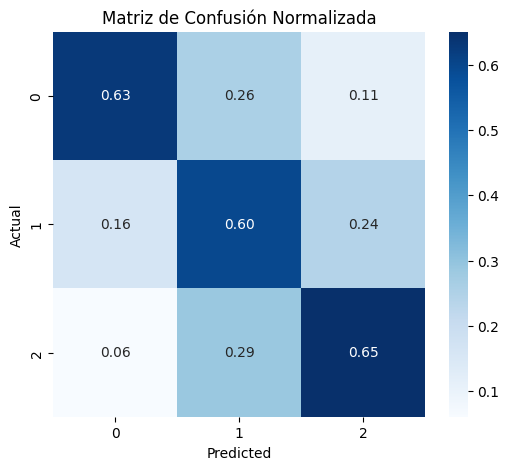

--- Evaluando Escenario: 1 ---
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_split': 5}

--- Métricas ---
Accuracy Train: 0.7069, F1 Train: 0.7166
Accuracy Test: 0.6267, F1 Test: 0.6401

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.85      0.63      0.72     11354
           1       0.42      0.60      0.49      5570
           2       0.59      0.65      0.62      5804

    accuracy                           0.63     22728
   macro avg       0.62      0.63      0.61     22728
weighted avg       0.68      0.63      0.64     22728



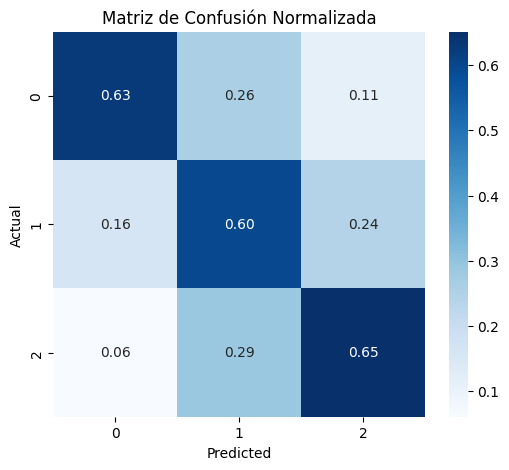

--- Evaluando Escenario: 2 ---
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_split': 10}

--- Métricas ---
Accuracy Train: 0.6317, F1 Train: 0.6451
Accuracy Test: 0.6132, F1 Test: 0.6278

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.86      0.60      0.70     11354
           1       0.41      0.65      0.50      5570
           2       0.59      0.61      0.60      5804

    accuracy                           0.61     22728
   macro avg       0.62      0.62      0.60     22728
weighted avg       0.68      0.61      0.63     22728



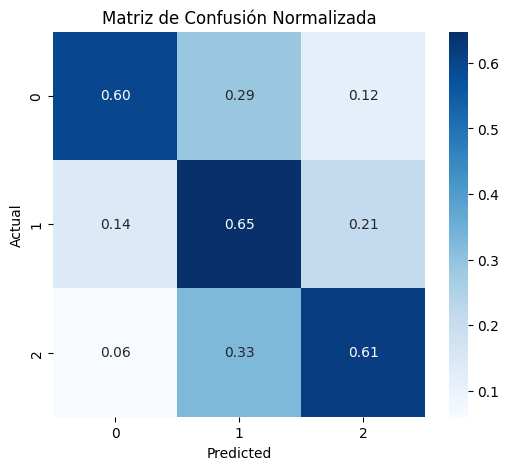

--- Evaluando Escenario: 3 ---
Mejores hiperparámetros encontrados: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_split': 5}

--- Métricas ---
Accuracy Train: 0.7270, F1 Train: 0.7356
Accuracy Test: 0.6964, F1 Test: 0.7059

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      7478
           1       0.48      0.59      0.53      3593
           2       0.66      0.78      0.71      3460

    accuracy                           0.70     14531
   macro avg       0.67      0.69      0.68     14531
weighted avg       0.73      0.70      0.71     14531



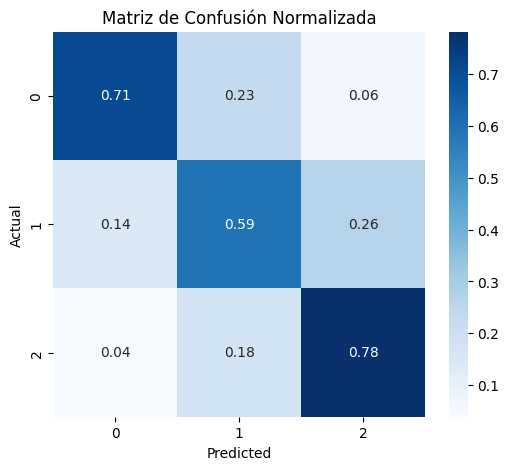

--- Evaluando Escenario: 4 ---
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 10, 'max_features': None, 'min_samples_split': 5}

--- Métricas ---
Accuracy Train: 0.6260, F1 Train: 0.6373
Accuracy Test: 0.5865, F1 Test: 0.5995

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.81      0.59      0.68     11354
           1       0.40      0.58      0.47      5570
           2       0.52      0.59      0.56      5804

    accuracy                           0.59     22728
   macro avg       0.58      0.59      0.57     22728
weighted avg       0.64      0.59      0.60     22728



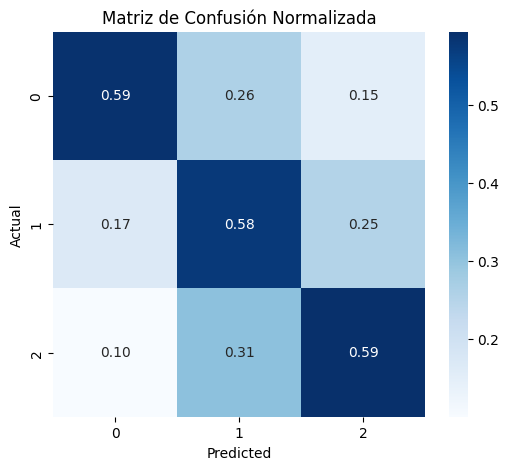

--- Evaluando Escenario: 5 ---
Mejores hiperparámetros encontrados: {'criterion': 'gini', 'max_depth': 15, 'max_features': None, 'min_samples_split': 5}

--- Métricas ---
Accuracy Train: 0.7107, F1 Train: 0.7199
Accuracy Test: 0.6263, F1 Test: 0.6390

Reporte de clasificación (Test):
              precision    recall  f1-score   support

           0       0.83      0.64      0.72     11354
           1       0.42      0.58      0.49      5570
           2       0.60      0.64      0.62      5804

    accuracy                           0.63     22728
   macro avg       0.62      0.62      0.61     22728
weighted avg       0.67      0.63      0.64     22728



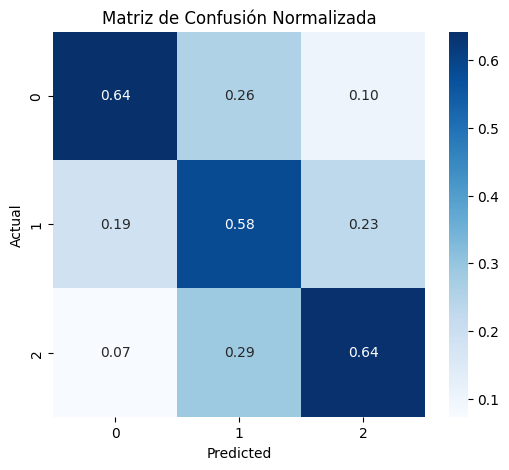

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------
# 1) Definir grilla mejorada
# ---------------------------
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Modelo base
modelo_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# Grid Search con CV=5 y scoring f1_weighted
grid_search = GridSearchCV(
    estimator=modelo_dt,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-2
)

# Escenarios con target categorizada
escenarios = {
    'Base': (X_train_final_escBase, X_test_final_escBase, y_train_final_escBase, y_test_final_escBase),
    '1': (X_train_final_esc1, X_test_final_esc1, y_train_final_esc1, y_test_final_esc1),
    '2': (X_train_final_esc2, X_test_final_esc2, y_train_final_esc2, y_test_final_esc2),
    '3': (X_train_final_esc3, X_test_final_esc3, y_train_final_esc3, y_test_final_esc3),
    '4': (X_train_final_esc4, X_test_final_esc4, y_train_final_esc4, y_test_final_esc4),
    '5': (X_train_final_esc5, X_test_final_esc5, y_train_final_esc5, y_test_final_esc5)
}

# Iterar sobre cada escenario
for nombre_escenario, (X_train, X_test, y_train, y_test) in escenarios.items():
    print(f"--- Evaluando Escenario: {nombre_escenario} ---")

    # ---------------------------
    # 2) Entrenar
    # ---------------------------
    grid_search.fit(X_train, y_train)

    # Mejor modelo
    mejor_dt = grid_search.best_estimator_
    print(f"Mejores hiperparámetros encontrados: {grid_search.best_params_}")

    # ---------------------------
    # 3) Predicciones
    # ---------------------------
    y_train_pred = mejor_dt.predict(X_train)
    y_test_pred = mejor_dt.predict(X_test)

    # ---------------------------
    # 4) Métricas
    # ---------------------------
    acc_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred, average='weighted')

    acc_test = accuracy_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred, average='weighted')

    print("\n--- Métricas ---")
    print(f"Accuracy Train: {acc_train:.4f}, F1 Train: {f1_train:.4f}")
    print(f"Accuracy Test: {acc_test:.4f}, F1 Test: {f1_test:.4f}")

    # ---------------------------
    # 5) Reporte de clasificación
    # ---------------------------
    print("\nReporte de clasificación (Test):")
    print(classification_report(y_test, y_test_pred))

    # ---------------------------
    # 6) Matriz de confusión normalizada
    # ---------------------------
    cm = confusion_matrix(y_test, y_test_pred, normalize='true')  # normaliza por filas
    df_cm = pd.DataFrame(cm, index=[0,1,2], columns=[0,1,2])

    plt.figure(figsize=(6,5))
    sns.heatmap(df_cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Matriz de Confusión Normalizada")
    plt.show()


# 4.CONCLUSIÓN

## El Decision Tree con GridSearchCV muestra leve overfitting pero mantiene una buena generalización relativa, tanto el conjunto de training como el de testeo son cercanos entre si y menores a 0,7.

## *Para mejorar la performance sería recomendable*:

*   Probar ensambles como "Random Forest o Gradient Boosting", que suelen aumentar el accuracy y F1 en problemas multiclase.

*   Mantener class_weight='balanced' para no favorecer la clase mayoritaria.

*   Tanto para este modelado como para la notebook de regresion, intentar encontrar mejores features que puedan predecir con mayor presicion la variable target.

